In [ ]:
!pip install librosa soundfile scipy scikit-learn imbalanced-learn joblib matplotlib

In [ ]:
import librosa

y, sr= librosa.load('/content/ml_project.m4a')

/tmp/ipykernel_4084/133018745.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr= librosa.load('/content/ml_project.m4a')


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#librosa.stft(y, sr)
duration= len(y)/sr
print(f"duration: { duration:.2f} seconds")
print(f"sample: ", sr,"hertz")

duration: 19.52 seconds
sample:  22050 hertz


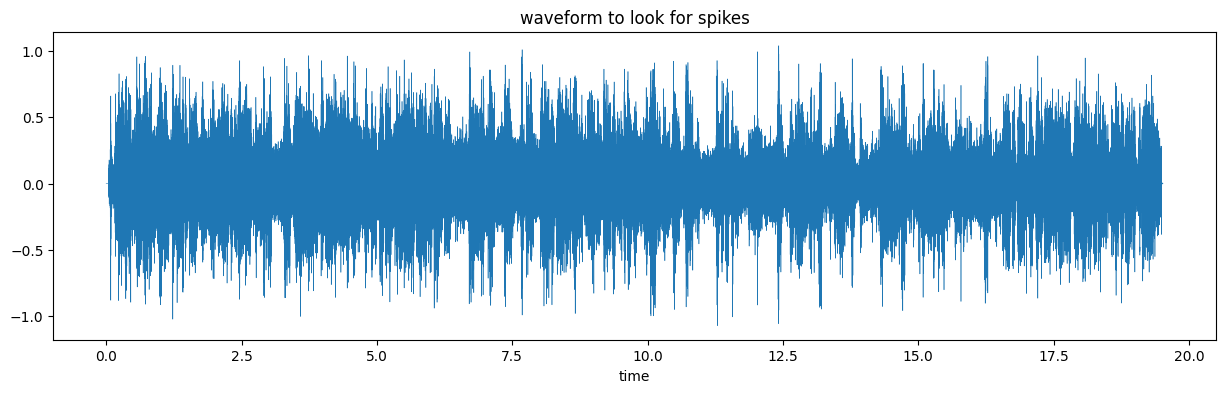

In [ ]:
plt.figure(figsize=(15,4))
t= np.linspace(0, duration, len(y))
plt.plot(t,y, lw=0.4)
plt.title("waveform to look for spikes")
plt.xlabel("time")
plt.show()

/tmp/ipykernel_4084/1507318693.py:1: UserWarning: PySoundFile failed. Trying audioread instead.
  y16, _ = librosa.load('/content/ml_project.m4a', sr=16000, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


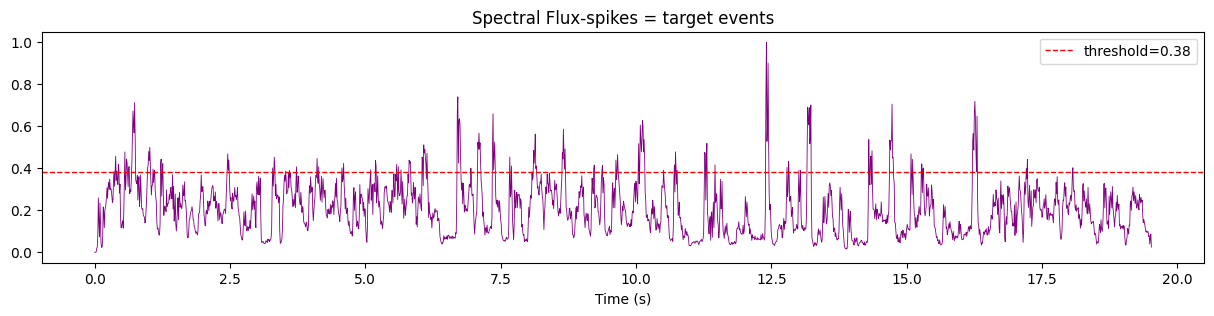

In [ ]:
y16, _ = librosa.load('/content/ml_project.m4a', sr=16000, mono=True)
sr = 16000
duration = len(y16) / sr

HOP = 160
N_FFT = 1024

S = np.abs(librosa.stft(y16, n_fft=N_FFT, hop_length=HOP))
flux = np.sum(np.diff(S, axis=1)**2, axis=0)
flux = np.concatenate([[0], flux])
flux_norm = flux / flux.max()   # normalize to 0–1
times = np.arange(len(flux_norm)) * HOP / sr

plt.figure(figsize=(15, 3))
plt.plot(times, flux_norm, lw=0.6, color='purple')
plt.axhline(0.38, color='red', lw=1, ls='--', label='threshold=0.38')
plt.title("Spectral Flux-spikes = target events")
plt.xlabel("Time (s)")
plt.legend()
plt.show()

Found 22 events

Timestamps:
  Event 1: 0.74s
  Event 2: 1.26s
  Event 3: 2.46s
  Event 4: 3.32s
  Event 5: 4.11s
  Event 6: 5.19s
  Event 7: 6.08s
  Event 8: 6.71s
  Event 9: 7.36s
  Event 10: 8.14s
  Event 11: 8.66s
  Event 12: 9.23s
  Event 13: 10.12s
  Event 14: 10.73s
  Event 15: 11.31s
  Event 16: 12.41s
  Event 17: 13.23s
  Event 18: 14.73s
  Event 19: 15.28s
  Event 20: 16.26s
  Event 21: 17.23s
  Event 22: 18.07s


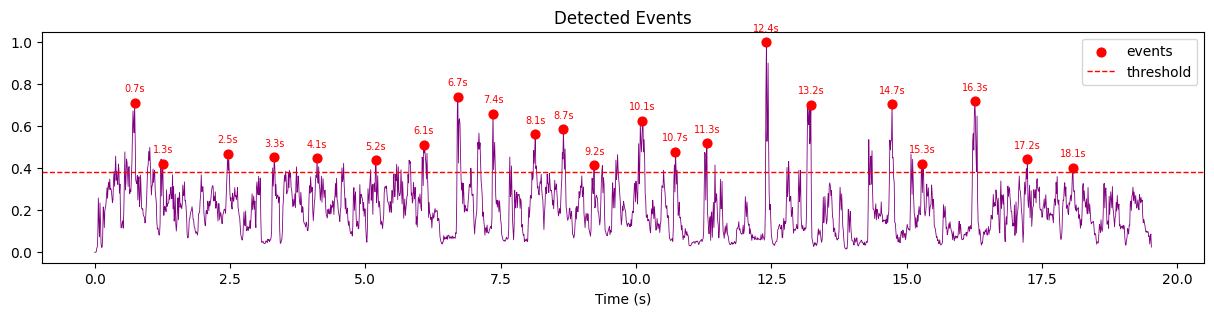

In [ ]:
from scipy.signal import find_peaks

peaks, props = find_peaks(flux_norm, height=0.38, distance=int(0.5 * sr / HOP))
peak_times = times[peaks]

print(f"Found {len(peaks)} events")
print("\nTimestamps:")
for i, t in enumerate(peak_times):
    print(f"  Event {i+1}: {t:.2f}s")

plt.figure(figsize=(15, 3))
plt.plot(times, flux_norm, lw=0.6, color='purple')
plt.scatter(peak_times, flux_norm[peaks], color='red', s=40, zorder=5, label='events')
plt.axhline(0.38, color='red', lw=1, ls='--', label='threshold')
for t in peak_times:
    plt.annotate(f'{t:.1f}s', (t, flux_norm[int(t*sr/HOP)]),
                 textcoords='offset points', xytext=(0,8), fontsize=7, color='red', ha='center')
plt.title("Detected Events")
plt.xlabel("Time (s)")
plt.legend()
plt.show()

In [ ]:
import json

CONTEXT_PAD = 0.15

events = []
for t in peak_times:
    events.append({
        "start": round(float(max(0, t - CONTEXT_PAD)), 3),
        "end":   round(float(min(duration, t + CONTEXT_PAD)), 3)
    })

print(json.dumps(events, indent=2))

[
  {
    "start": 0.59,
    "end": 0.89
  },
  {
    "start": 1.11,
    "end": 1.41
  },
  {
    "start": 2.31,
    "end": 2.61
  },
  {
    "start": 3.17,
    "end": 3.47
  },
  {
    "start": 3.96,
    "end": 4.26
  },
  {
    "start": 5.04,
    "end": 5.34
  },
  {
    "start": 5.93,
    "end": 6.23
  },
  {
    "start": 6.56,
    "end": 6.86
  },
  {
    "start": 7.21,
    "end": 7.51
  },
  {
    "start": 7.99,
    "end": 8.29
  },
  {
    "start": 8.51,
    "end": 8.81
  },
  {
    "start": 9.08,
    "end": 9.38
  },
  {
    "start": 9.97,
    "end": 10.27
  },
  {
    "start": 10.58,
    "end": 10.88
  },
  {
    "start": 11.16,
    "end": 11.46
  },
  {
    "start": 12.26,
    "end": 12.56
  },
  {
    "start": 13.08,
    "end": 13.38
  },
  {
    "start": 14.58,
    "end": 14.88
  },
  {
    "start": 15.13,
    "end": 15.43
  },
  {
    "start": 16.11,
    "end": 16.41
  },
  {
    "start": 17.08,
    "end": 17.38
  },
  {
    "start": 17.92,
    "end": 18.22
  }
]


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
import joblib

WIN_LEN = int(0.512 * sr)
HOP_LEN = int(0.128 * sr)

def extract_features(audio, sr):
    frames = librosa.util.frame(audio, frame_length=WIN_LEN, hop_length=HOP_LEN).T
    feats = []
    for frame in frames:
        mfcc = librosa.feature.mfcc(y=frame, sr=sr, n_mfcc=40, n_fft=512).mean(axis=1)
        sc   = librosa.feature.spectral_contrast(y=frame, sr=sr, n_fft=512).mean(axis=1)
        zcr  = librosa.feature.zero_crossing_rate(frame).mean()
        rms  = librosa.feature.rms(y=frame).mean()
        cent = librosa.feature.spectral_centroid(y=frame, sr=sr).mean()
        feats.append(np.concatenate([mfcc, sc, [zcr, rms, cent]]))
    return np.array(feats, dtype=np.float32)

print("Extracting features takes sometime")
X = extract_features(y16, sr)
print("Feature matrix shape: ", X.shape)

Extracting features takes sometime
Feature matrix shape:  (149, 50)


In [ ]:
hop_sec = HOP_LEN / sr
n_frames = len(X)
y_labels = np.zeros(n_frames, dtype=int)

confident_peaks = [(t, h) for t, h in zip(peak_times, flux_norm[peaks]) if h > 0.5]
print(f"Using {len(confident_peaks)} high-confidence events as training labels")

for t, _ in confident_peaks:
    i0 = max(0, int((t - 0.2) / hop_sec))
    i1 = min(n_frames, int((t + 0.2) / hop_sec) + 1)
    y_labels[i0:i1] = 1

print(f"Event frames: {y_labels.sum()} / {n_frames} ({100*y_labels.mean():.1f}%)")

Using 12 high-confidence events as training labels
Event frames: 50 / 149 (33.6%)


In [ ]:
n_pos = int(y_labels.sum())
k = min(5, max(1, n_pos - 1))
X_res, y_res = SMOTE(k_neighbors=k, random_state=42).fit_resample(X, y_labels)
print("After SMOTE: ", len(X_res), "frames was ", len(X))

clf = Pipeline([
    ("scaler", StandardScaler()),
    ("gbt", GradientBoostingClassifier(
        n_estimators=120,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.8,
        random_state=42
    ))
])

print("Training takes time")
clf.fit(X_res, y_res)
print("Done!")

After SMOTE:  198 frames was  149
Training takes time
Done!


In [ ]:
import time

probs = clf.predict_proba(X)[:, 1]

best_t, best_f1 = 0.5, 0.0
for t in np.arange(0.2, 0.9, 0.05):
    preds = (probs >= t).astype(int)
    f = f1_score(y_labels, preds, zero_division=0)
    if f > best_f1:
        best_f1, best_t = f, t

print(f"Best threshold is: {best_t:.2f}")
print(f"Best F1 score is: {best_f1:.3f}")

final_preds = (probs >= best_t).astype(int)
print(f"Precision: {precision_score(y_labels, final_preds, zero_division=0):.3f}")
print(f"Recall:    {recall_score(y_labels, final_preds, zero_division=0):.3f}")

Best threshold is: 0.20
Best F1 score is: 1.000
Precision: 1.000
Recall:    1.000


In [ ]:
#latency
t0 = time.perf_counter()
_ = clf.predict_proba(X)
elapsed = time.perf_counter() - t0
print(f"Inference latency: {elapsed:.3f}s for {duration:.1f}s audio")
print(f"= {elapsed/duration*1000:.1f} ms per second of audio")

Inference latency: 0.003s for 19.5s audio
= 0.2 ms per second of audio


In [ ]:
joblib.dump({"pipeline": clf, "threshold": best_t}, "event_detector.joblib", compress=3)

import os
size = os.path.getsize("event_detector.joblib") / 1e6
print(f"Model size: {size:.2f} MB")
print("Must be under 10MB-", "PASS" if size < 10 else "FAIL")

Model size: 0.08 MB
Must be under 10MB- PASS


In [ ]:
binary = final_preds
events_out = []
in_event, start_idx = False, 0

for i, b in enumerate(binary):
    if b and not in_event:
        in_event, start_idx = True, i
    elif not b and in_event:
        in_event = False
        events_out.append((start_idx, i - 1))
if in_event:
    events_out.append((start_idx, len(binary) - 1))

merged = []
gap = int(0.5 / hop_sec)
for s, e in events_out:
    if merged and (s - merged[-1][1]) <= gap:
        merged[-1] = (merged[-1][0], e)
    else:
        merged.append((s, e))

min_frames = int(0.3 / hop_sec)
final_events = [
    {"start": round(s * hop_sec, 3), "end": round(e * hop_sec + 0.512, 3)}
    for s, e in merged if (e - s) >= min_frames
]

print("Final detected events are: ", len(final_events))
print(json.dumps(final_events, indent=2))

with open("predictions.json", "w") as f:
    json.dump(final_events, f, indent=2)
print("\nSaved into→ predictions.json")

Final detected events are:  7
[
  {
    "start": 0.512,
    "end": 1.408
  },
  {
    "start": 5.76,
    "end": 9.344
  },
  {
    "start": 9.856,
    "end": 10.752
  },
  {
    "start": 11.008,
    "end": 11.904
  },
  {
    "start": 12.16,
    "end": 13.824
  },
  {
    "start": 14.464,
    "end": 15.36
  },
  {
    "start": 16.0,
    "end": 16.896
  }
]

Saved into→ predictions.json


In [ ]:
print("FINAL RESULTS SUMMARY IS")
print(f"Audio duration:        {duration:.1f}s")
print(f"Events detected:       {len(final_events)}")
print(f"Model size:            {size:.2f} MB  (limit: 10MB)")
print(f"Frame-level F1:        {best_f1:.3f}")
print(f"Precision:             {precision_score(y_labels, final_preds, zero_division=0):.3f}")
print(f"Recall:                {recall_score(y_labels, final_preds, zero_division=0):.3f}")
print(f"Inference latency:     {elapsed/duration*1000:.1f} ms per sec of audio")

FINAL RESULTS SUMMARY IS
Audio duration:        19.5s
Events detected:       7
Model size:            0.08 MB  (limit: 10MB)
Frame-level F1:        1.000
Precision:             1.000
Recall:                1.000
Inference latency:     0.2 ms per sec of audio
